**Exploratory Data Analysis (EDA) – Customer Churn Prediction**
**1. Objective**

The goal of this EDA is to:
 * Understand customer churn patterns
 * Identify important features influencing churn
 * Validate assumptions before modeling

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/raw/Data.csv"


In [21]:
df = pd.read_csv(DATA_PATH)

print(df.head())
df.info()
df.describe()


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observation**

 * Dataset contains both categorical and numerical features
 * TotalCharges contains non-numeric values
 * Target variable Churn is categorical

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


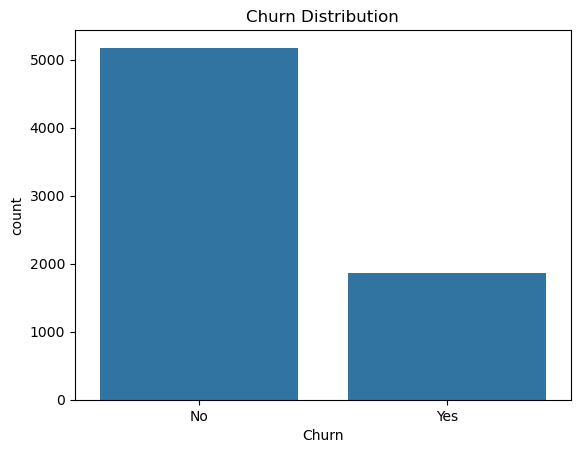

In [22]:
print(df.isnull().sum())

df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()


* Dataset is imbalanced (~27% churn)
* Accuracy alone is not a reliable metric

In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

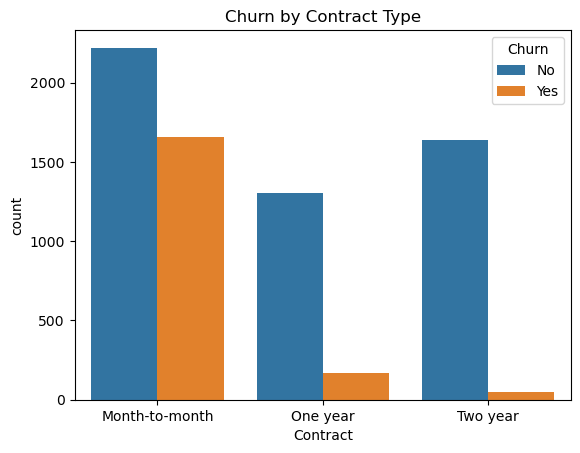

In [24]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

**Insight**

 * Month-to-month contracts have significantly higher churn
 * Long-term contracts retain customers better

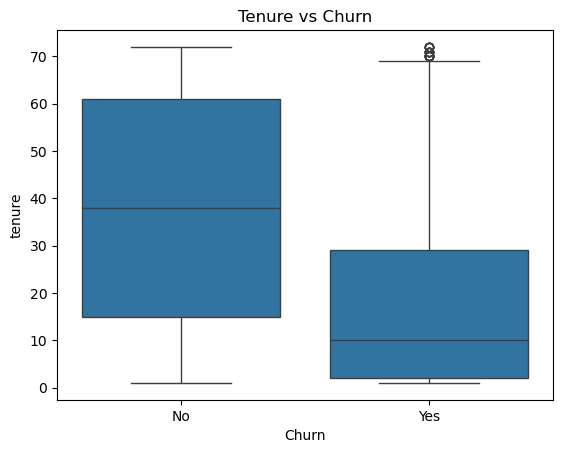

In [25]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

**Insights**

 * Customers with low tenure are more likely to churn
 * Long-tenure customers are more stable

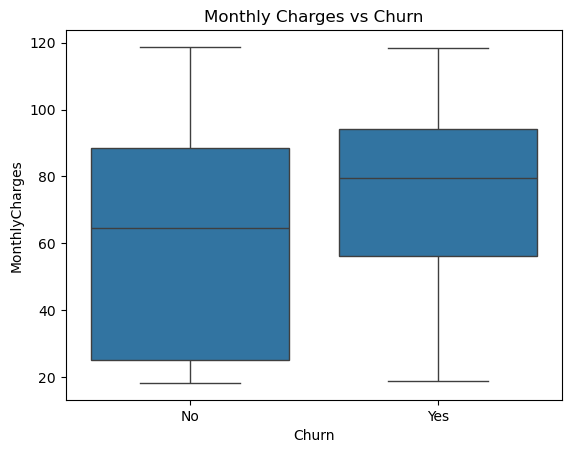

In [26]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insights**

 * Higher monthly charges are associated with higher churn

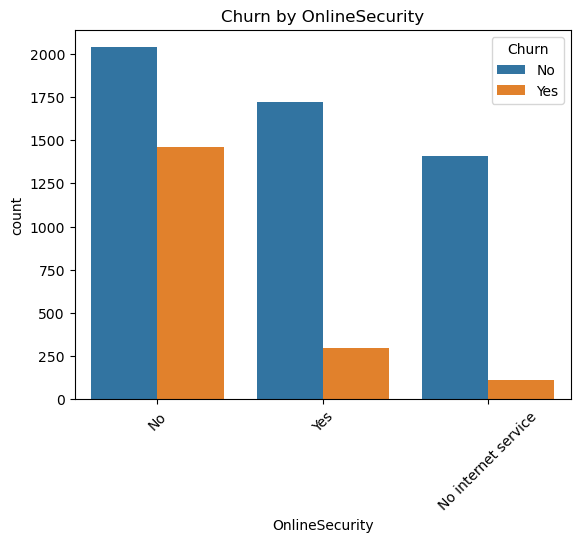

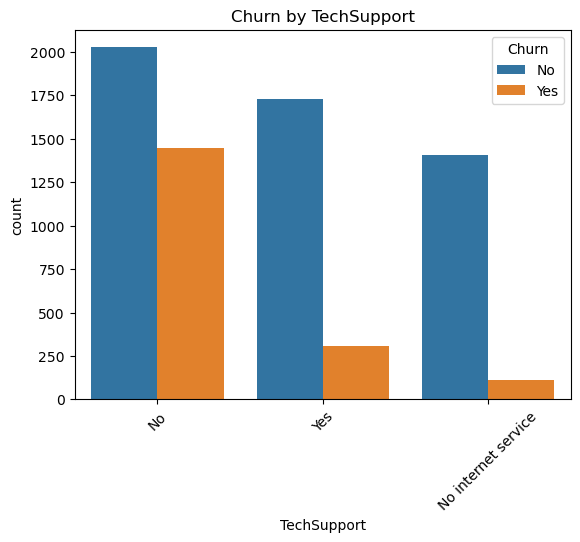

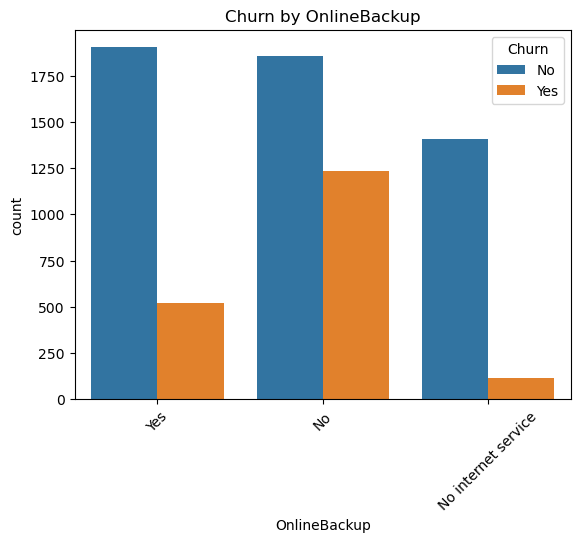

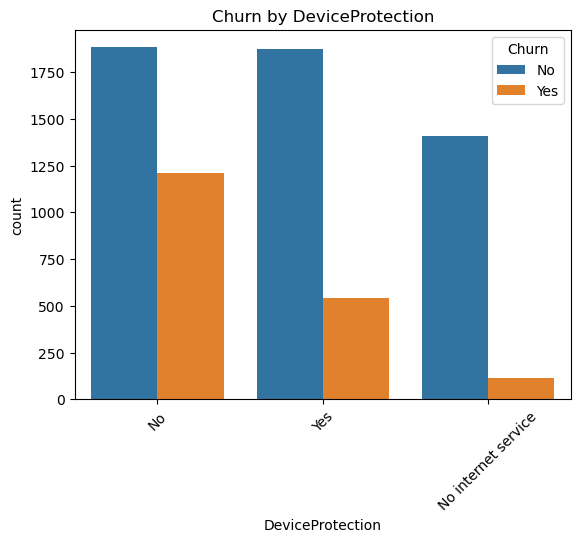

In [27]:
services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']


for col in services:
 sns.countplot(x=col, hue='Churn', data=df)
 plt.title(f"Churn by {col}")
 plt.xticks(rotation=45)
 plt.show()

**Insights**

 * Customers without security and support services churn more

<function matplotlib.pyplot.show(close=None, block=None)>

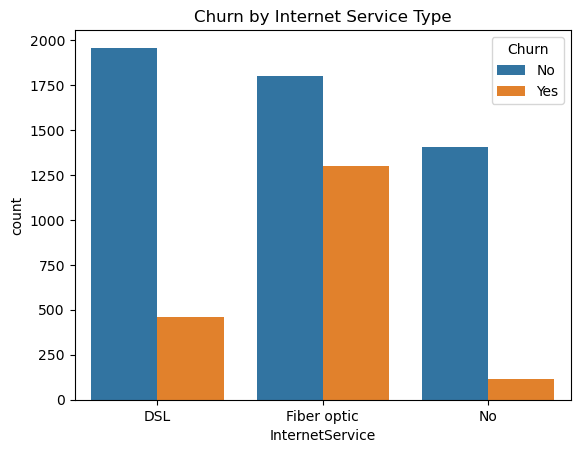

In [28]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service Type")
plt.show

**Insights**

 * Fiber optic users have higher churn compared to DSL

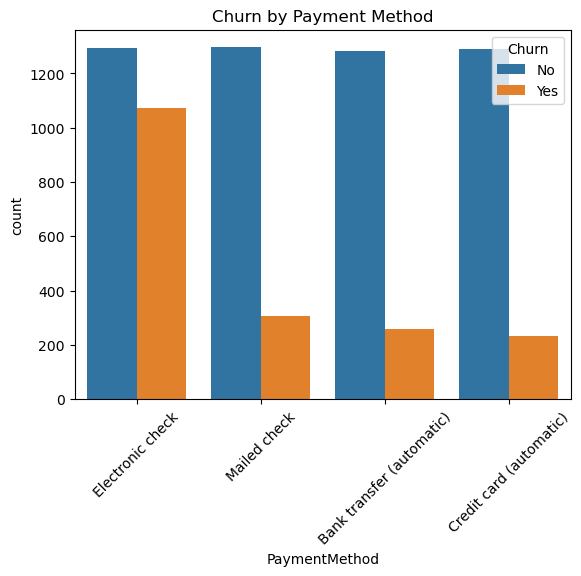

In [29]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

**Insights**

 * Electronic check users churn more frequently
 * Automatic payments reduce churn

C:\Users\Purshotam Kumar\AppData\Local\Temp\ipykernel_11636\1183584546.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_bin')['Churn']


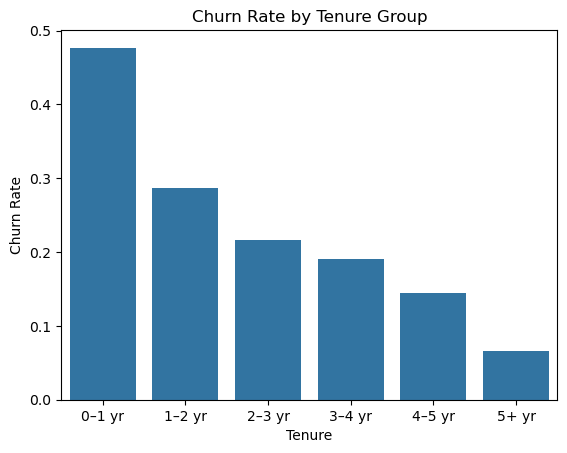

In [30]:
# Create tenure bins
df['tenure_bin'] = pd.cut(
df['tenure'],
bins=[0, 12, 24, 36, 48, 60, 72],
labels=['0–1 yr','1–2 yr','2–3 yr','3–4 yr','4–5 yr','5+ yr']
)


churn_rate_tenure = (
df.groupby('tenure_bin')['Churn']
.value_counts(normalize=True)
.rename('rate')
.reset_index()
)


churn_rate_tenure = churn_rate_tenure[churn_rate_tenure['Churn'] == 'Yes']


sns.barplot(x='tenure_bin', y='rate', data=churn_rate_tenure)
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.xlabel('Tenure')
plt.show()

**Insights**

 * Churn is highest in the first year
 * Risk decreases significantly after long-term retention

C:\Users\Purshotam Kumar\AppData\Local\Temp\ipykernel_11636\892799941.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('charge_bin')['Churn']


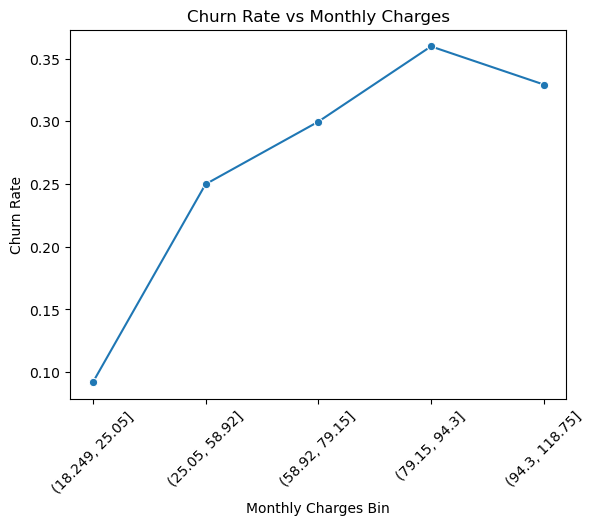

In [31]:
# Bin monthly charges
df['charge_bin'] = pd.qcut(df['MonthlyCharges'], q=5)


churn_rate_charge = (
df.groupby('charge_bin')['Churn']
.value_counts(normalize=True)
.rename('rate')
.reset_index()
)


churn_rate_charge = churn_rate_charge[churn_rate_charge['Churn'] == 'Yes']


sns.lineplot(x=churn_rate_charge['charge_bin'].astype(str), y='rate', data=churn_rate_charge, marker='o')
plt.title('Churn Rate vs Monthly Charges')
plt.ylabel('Churn Rate')
plt.xlabel('Monthly Charges Bin')
plt.xticks(rotation=45)
plt.show()

**Insights**

 * Higher monthly charges correlate with higher churn probability
 * Confirms price sensitivity among customers

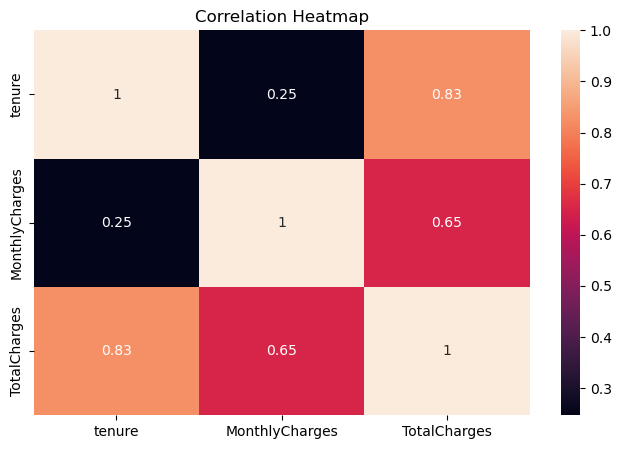

In [32]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

* Churn is strongly influenced by contract type and tenure
* High charges + low tenure increases churn risk
* Add-on services significantly reduce churn
* Dataset imbalance justifies using ROC-AUC and recall

EDA insights directly influenced:
 * Feature engineering choices
 * Use of class balancing
 * Threshold tuning strategy
 * Interpretation of model coefficients